# Panel Builder: Sovereign CCA Dataset

Builds a model-agnostic panel dataset for structural credit risk analysis.

**Data sources:**
- QEDS: Quarterly external debt (General Government)
- MSCI: Country equity indices (daily → weekly)
- CDS: Sovereign CDS spreads (weekly)
- DGS1: 1-Year US Treasury rate (risk-free rate)

**Output:**
- `data/processed/cca_panel.csv` — ready for model testing

**Panel is model-agnostic:** No d₂, PD, or spread calculations. Those happen in model notebooks.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [3]:
# =============================================================================
# PATHS
# =============================================================================
QEDS_PATH = "data/processed/WB_QEDS/QEDS_SDDS.csv"
MSCI_PATH = "data/processed/MSCI_indices/mscicountryindex.csv"
CDS_PATH = "data/processed/CDS/Weekly_CDS.csv"
RF_PATH = "data/processed/Macroeconomic_variables/DGS1.csv"

OUTPUT_PATH = "data/processed/merton_panel.csv"

In [5]:
# =============================================================================
# FILTER CONFIGURATION
# =============================================================================

# MSCI Emerging Markets countries
MSCI_EM_COUNTRIES = [
    'brazil', 'chile', 'china', 'colombia', 'czechia', 'egypt',
    'greece', 'hungary', 'india', 'indonesia', 'south korea',
    'malaysia', 'mexico', 'peru', 'philippines', 'poland',
    'saudi arabia', 'south africa', 'thailand', 'turkey'
]

# Oil exporters vs controls (for later analysis)
OIL_EXPORTERS = ['saudi arabia', 'colombia', 'mexico', 'brazil', 'egypt', 'malaysia']
CONTROLS = ['indonesia', 'philippines', 'turkey', 'chile', 'china', 
            'south africa', 'south korea', 'thailand']

# Date range
DATE_START = '2014-01-01'
DATE_END = '2024-12-31'

---
## 1. Load QEDS (Quarterly External Debt)

In [6]:
DEBT_INDICATORS = {
    'debt_st': 'Gross Ext. Debt Pos., General Government, Short-term, All instruments, USD',
    'debt_lt': 'Gross Ext. Debt Pos., General Government, Long-term, All instruments, USD',
}

def load_qeds(path):
    """Load QEDS data and reshape to long format."""
    print(f"Loading QEDS from {path}...")
    df = pd.read_csv(path, delimiter=';')
    
    # Identify quarter columns
    quarter_cols = [c for c in df.columns if c not in ['Cleaned_Name', 'Indicator Name'] 
                    and len(c) == 6 and 'Q' in c]
    print(f"  Found {len(quarter_cols)} quarters: {quarter_cols[0]} to {quarter_cols[-1]}")
    
    # Melt to long format
    df_long = df.melt(
        id_vars=['Cleaned_Name', 'Indicator Name'],
        value_vars=quarter_cols,
        var_name='quarter',
        value_name='value'
    )
    df_long.columns = ['country', 'indicator', 'quarter', 'value']
    
    # Quarter to date
    df_long['date'] = pd.to_datetime(
        df_long['quarter'].str.replace('Q1', '-03-31')
                          .str.replace('Q2', '-06-30')
                          .str.replace('Q3', '-09-30')
                          .str.replace('Q4', '-12-31')
    )
    df_long['value'] = pd.to_numeric(df_long['value'], errors='coerce')
    
    print(f"  Loaded {len(df_long)} rows, {df_long['country'].nunique()} countries")
    return df_long


def extract_debt_variables(qeds_long):
    """Extract General Government debt and compute default barrier."""
    print("Extracting debt variables...")
    
    available = qeds_long['indicator'].unique()
    matched = {k: v for k, v in DEBT_INDICATORS.items() if v in available}
    print(f"  Matched indicators: {list(matched.keys())}")
    
    if not matched:
        raise ValueError("No matching debt indicators found")
    
    debt_data = qeds_long[qeds_long['indicator'].isin(matched.values())].copy()
    inv_map = {v: k for k, v in matched.items()}
    debt_data['var'] = debt_data['indicator'].map(inv_map)
    
    debt_wide = debt_data.pivot_table(
        index=['country', 'date'],
        columns='var',
        values='value',
        aggfunc='first'
    ).reset_index()
    debt_wide.columns.name = None
    
    # Default barrier: ST + 0.5 × LT
    debt_wide['default_barrier'] = (
        debt_wide['debt_st'].fillna(0) + 0.5 * debt_wide['debt_lt'].fillna(0)
    )
    
    print(f"  Output: {len(debt_wide)} country-quarter observations")
    return debt_wide


def expand_debt_to_weekly(debt_quarterly, weekly_dates):
    """Forward-fill quarterly debt to weekly frequency."""
    print("Expanding debt to weekly (forward-fill)...")
    
    debt_list = []
    for country in debt_quarterly['country'].unique():
        cq = debt_quarterly[debt_quarterly['country'] == country].copy()
        if len(cq) == 0:
            continue
        
        min_d, max_d = cq['date'].min(), cq['date'].max()
        weeks = weekly_dates[(weekly_dates >= min_d) & 
                             (weekly_dates <= max_d + pd.Timedelta(days=100))].tolist()
        if len(weeks) == 0:
            continue
        
        wdf = pd.DataFrame({'date': weeks, 'country': country})
        wdf = wdf.merge(cq[['date', 'debt_st', 'debt_lt', 'default_barrier']], 
                        on='date', how='left')
        wdf = wdf.sort_values('date')
        wdf[['debt_st', 'debt_lt', 'default_barrier']] = \
            wdf[['debt_st', 'debt_lt', 'default_barrier']].ffill()
        debt_list.append(wdf)
    
    debt_weekly = pd.concat(debt_list, ignore_index=True)
    print(f"  Output: {len(debt_weekly)} country-week observations")
    return debt_weekly

In [7]:
# Load and process QEDS
qeds_long = load_qeds(QEDS_PATH)
debt_quarterly = extract_debt_variables(qeds_long)

Loading QEDS from data/processed/WB_QEDS/QEDS_SDDS.csv...
  Found 110 quarters: 1998Q1 to 2025Q2
  Loaded 25542000 rows, 129 countries
Extracting debt variables...
  Matched indicators: ['debt_st', 'debt_lt']
  Output: 8905 country-quarter observations


---
## 2. Load MSCI (Daily → Weekly)

In [8]:
def load_msci(path):
    """Load MSCI country indices (daily, wide format → long)."""
    print(f"Loading MSCI from {path}...")
    df = pd.read_csv(path, delimiter=',')
    
    date_col = df.columns[0]
    df['date'] = pd.to_datetime(df[date_col], format='%d.%m.%Y', errors='coerce')
    if df['date'].isna().all():
        df['date'] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.drop(columns=[date_col])
    
    country_cols = [c for c in df.columns if c != 'date']
    print(f"  Found {len(country_cols)} countries")
    
    df_long = df.melt(
        id_vars=['date'],
        value_vars=country_cols,
        var_name='country',
        value_name='msci_index'
    )
    df_long['msci_index'] = pd.to_numeric(df_long['msci_index'], errors='coerce')
    df_long = df_long.dropna(subset=['date', 'msci_index'])
    
    print(f"  Date range: {df_long['date'].min()} to {df_long['date'].max()}")
    print(f"  Loaded {len(df_long)} daily observations")
    return df_long


def compute_msci_weekly(msci_daily):
    """Aggregate daily MSCI to weekly (Friday close + rolling vol)."""
    print("Computing weekly MSCI statistics...")
    df = msci_daily.copy()
    
    # Week-ending Friday
    df['week'] = df['date'].apply(
        lambda d: d + pd.Timedelta(days=(4 - d.dayofweek) % 7) if d.dayofweek <= 4 
                  else d + pd.Timedelta(days=(4 - d.dayofweek + 7))
    )
    
    # Log returns
    df = df.sort_values(['country', 'date'])
    df['log_ret'] = df.groupby('country')['msci_index'].transform(
        lambda x: np.log(x / x.shift(1))
    )
    
    # Weekly aggregation
    weekly = df.groupby(['country', 'week']).agg(
        msci_index=('msci_index', 'last'),
        msci_ret_weekly=('log_ret', 'sum'),
        n_trading_days=('log_ret', 'count')
    ).reset_index()
    weekly.columns = ['country', 'date', 'msci_index', 'msci_ret_weekly', 'n_trading_days']
    
    # Rolling 52-week annualized volatility
    weekly = weekly.sort_values(['country', 'date'])
    weekly['msci_vol_52w'] = weekly.groupby('country')['msci_ret_weekly'].transform(
        lambda x: x.rolling(window=52, min_periods=12).std() * np.sqrt(52)
    )
    
    print(f"  Output: {len(weekly)} country-week observations")
    return weekly

In [9]:
# Load and process MSCI
msci_daily = load_msci(MSCI_PATH)
msci_weekly = compute_msci_weekly(msci_daily)

Loading MSCI from data/processed/MSCI_indices/mscicountryindex.csv...
  Found 85 countries
  Date range: 1999-12-31 00:00:00 to 2024-12-31 00:00:00
  Loaded 470553 daily observations
Computing weekly MSCI statistics...
  Output: 94201 country-week observations


---
## 3. Load CDS Spreads

In [10]:
def load_cds(path):
    """Load CDS spreads (wide format → long)."""
    print(f"Loading CDS from {path}...")
    df = pd.read_csv(path)
    
    date_col = df.columns[0]
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    if df['date'].isna().sum() > len(df) * 0.5:
        df['date'] = pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df = df.drop(columns=[date_col])
    
    country_cols = [c for c in df.columns if c != 'date']
    print(f"  Found {len(country_cols)} countries")
    
    df_long = df.melt(
        id_vars=['date'],
        value_vars=country_cols,
        var_name='country',
        value_name='cds_spread'
    )
    df_long['cds_spread'] = pd.to_numeric(df_long['cds_spread'], errors='coerce')
    df_long = df_long.dropna(subset=['date', 'cds_spread'])
    
    print(f"  Date range: {df_long['date'].min()} to {df_long['date'].max()}")
    print(f"  Loaded {len(df_long)} observations")
    return df_long

In [11]:
cds = load_cds(CDS_PATH)

Loading CDS from data/processed/CDS/Weekly_CDS.csv...
  Found 72 countries
  Date range: 2007-12-14 00:00:00 to 2024-12-27 00:00:00
  Loaded 61302 observations


---
## 4. Load Risk-Free Rate

In [12]:
def load_rf(path):
    """Load 1Y Treasury rate."""
    print(f"Loading risk-free rate from {path}...")
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['Date'], errors='coerce')
    df['rf'] = pd.to_numeric(df['DGS1'], errors='coerce') / 100  # % to decimal
    df = df[['date', 'rf']].dropna()
    
    # Resample to weekly Friday
    df_weekly = df.set_index('date').resample('W-FRI').last().reset_index()
    
    print(f"  Date range: {df_weekly['date'].min()} to {df_weekly['date'].max()}")
    print(f"  Loaded {len(df_weekly)} weekly observations")
    return df_weekly

In [13]:
rf = load_rf(RF_PATH)

Loading risk-free rate from data/processed/Macroeconomic_variables/DGS1.csv...
  Date range: 1962-01-05 00:00:00 to 2026-01-30 00:00:00
  Loaded 3344 weekly observations


---
## 5. Merge All Datasets

In [14]:
def standardize_country(name):
    """Standardize country names for matching."""
    return name.strip().lower()

# Get weekly dates from MSCI
weekly_dates = msci_weekly['date'].drop_duplicates().sort_values()

# Expand debt to weekly
debt_weekly = expand_debt_to_weekly(debt_quarterly, weekly_dates)

# Standardize country names
debt_weekly['country_clean'] = debt_weekly['country'].apply(standardize_country)
msci_weekly['country_clean'] = msci_weekly['country'].apply(standardize_country)
cds['country_clean'] = cds['country'].apply(standardize_country)

Expanding debt to weekly (forward-fill)...
  Output: 112142 country-week observations


In [15]:
# Check overlaps
debt_c = set(debt_weekly['country_clean'].unique())
msci_c = set(msci_weekly['country_clean'].unique())
cds_c = set(cds['country_clean'].unique())

overlap_all = debt_c & msci_c & cds_c
overlap_em = overlap_all & set(MSCI_EM_COUNTRIES)

print(f"QEDS countries: {len(debt_c)}")
print(f"MSCI countries: {len(msci_c)}")
print(f"CDS countries: {len(cds_c)}")
print(f"Three-way overlap: {len(overlap_all)}")
print(f"MSCI EM overlap: {len(overlap_em)}")
print(f"\nMatched EM countries: {sorted(overlap_em)}")

QEDS countries: 129
MSCI countries: 85
CDS countries: 72
Three-way overlap: 53
MSCI EM overlap: 20

Matched EM countries: ['brazil', 'chile', 'china', 'colombia', 'czechia', 'egypt', 'greece', 'hungary', 'india', 'indonesia', 'malaysia', 'mexico', 'peru', 'philippines', 'poland', 'saudi arabia', 'south africa', 'south korea', 'thailand', 'turkey']


In [16]:
# Merge MSCI + Debt
print("\nMerging datasets...")
panel = msci_weekly.merge(
    debt_weekly[['country_clean', 'date', 'debt_st', 'debt_lt', 'default_barrier']],
    on=['country_clean', 'date'],
    how='inner'
)
print(f"  After MSCI + Debt: {len(panel)} obs, {panel['country'].nunique()} countries")

# Merge CDS
panel = panel.merge(
    cds[['country_clean', 'date', 'cds_spread']],
    on=['country_clean', 'date'],
    how='inner'
)
print(f"  After + CDS: {len(panel)} obs, {panel['country'].nunique()} countries")

# Merge RF
panel = panel.merge(rf, on='date', how='left')
panel['rf'] = panel['rf'].ffill().fillna(0.02)  # Fallback
print(f"  After + RF: {len(panel)} obs")


Merging datasets...
  After MSCI + Debt: 61958 obs, 65 countries
  After + CDS: 42329 obs, 53 countries
  After + RF: 42329 obs


---
## 6. Filter and Clean

In [17]:
# Filter to MSCI EM countries
panel = panel[panel['country_clean'].isin(MSCI_EM_COUNTRIES)]
print(f"After EM filter: {len(panel)} obs, {panel['country'].nunique()} countries")

# Filter date range
panel = panel[(panel['date'] >= DATE_START) & (panel['date'] <= DATE_END)]
print(f"After date filter: {len(panel)} obs")

# Drop rows with missing critical variables
critical_cols = ['msci_index', 'msci_vol_52w', 'default_barrier', 'cds_spread']
panel = panel.dropna(subset=critical_cols)
print(f"After dropna: {len(panel)} obs")

After EM filter: 16018 obs, 20 countries
After date filter: 11195 obs
After dropna: 10961 obs


In [18]:
# Add group labels (oil exporter vs control)
panel['group'] = panel['country_clean'].apply(
    lambda x: 'oil_exporter' if x in OIL_EXPORTERS 
              else ('control' if x in CONTROLS else 'other')
)

print("\nGroup distribution:")
print(panel.groupby('group').agg(
    n_countries=('country', 'nunique'),
    n_obs=('country', 'count')
))


Group distribution:
              n_countries  n_obs
group                           
control                 8   4449
oil_exporter            6   3132
other                   6   3380


In [19]:
# Clean up columns
panel = panel.sort_values(['country', 'date']).reset_index(drop=True)

# Final column order
panel = panel[[
    'country', 'country_clean', 'group', 'date',
    'msci_index', 'msci_ret_weekly', 'msci_vol_52w', 'n_trading_days',
    'debt_st', 'debt_lt', 'default_barrier',
    'cds_spread', 'rf'
]]

print(f"\nFinal columns: {list(panel.columns)}")


Final columns: ['country', 'country_clean', 'group', 'date', 'msci_index', 'msci_ret_weekly', 'msci_vol_52w', 'n_trading_days', 'debt_st', 'debt_lt', 'default_barrier', 'cds_spread', 'rf']


---
## 7. Summary and Export

In [20]:
print("="*60)
print("PANEL SUMMARY")
print("="*60)
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")
print(f"Countries: {panel['country'].nunique()}")
print(f"Total observations: {len(panel)}")
print(f"\nCountries: {sorted(panel['country'].unique())}")

print("\nObservations by country:")
print(panel.groupby('country').size().sort_values(ascending=False))

PANEL SUMMARY
Date range: 2014-01-03 to 2024-12-27
Countries: 20
Total observations: 10961

Countries: ['Brazil', 'Chile', 'China', 'Colombia', 'Czechia', 'Egypt', 'Greece', 'Hungary', 'India', 'Indonesia', 'Malaysia', 'Mexico', 'Peru', 'Philippines', 'Poland', 'Saudi Arabia', 'South Africa', 'South Korea', 'Thailand', 'Turkey']

Observations by country:
country
Brazil          574
Chile           574
Thailand        574
South Korea     574
South Africa    574
Poland          574
Philippines     574
Peru            574
Mexico          574
Turkey          574
Indonesia       574
Hungary         574
Greece          574
Egypt           574
Czechia         574
Colombia        574
India           510
China           431
Malaysia        431
Saudi Arabia    405
dtype: int64


In [21]:
print("\nMissing values:")
print(panel.isnull().sum())

print("\nSample:")
panel.head(10)


Missing values:
country            0
country_clean      0
group              0
date               0
msci_index         0
msci_ret_weekly    0
msci_vol_52w       0
n_trading_days     0
debt_st            0
debt_lt            0
default_barrier    0
cds_spread         0
rf                 0
dtype: int64

Sample:


,country,country_clean,group,date,msci_index,msci_ret_weekly,msci_vol_52w,n_trading_days,debt_st,debt_lt,default_barrier,cds_spread,rf
0,Brazil,brazil,oil_exporter,2014-01-03,804.695,-0.023366,0.220537,5,0.0,5.867838e+10,2.933919e+10,187.25,0.0013
1,Brazil,brazil,oil_exporter,2014-01-10,788.350,-0.020521,0.220925,5,0.0,5.867838e+10,2.933919e+10,191.83,0.0012
2,Brazil,brazil,oil_exporter,2014-01-17,780.773,-0.009658,0.220657,5,0.0,5.867838e+10,2.933919e+10,194.64,0.0011
3,Brazil,brazil,oil_exporter,2014-01-24,743.312,-0.049169,0.224817,5,0.0,5.867838e+10,2.933919e+10,206.22,0.0011
4,Brazil,brazil,oil_exporter,2014-01-31,737.863,-0.007358,0.223771,5,0.0,5.867838e+10,2.933919e+10,205.43,0.0010
5,Brazil,brazil,oil_exporter,2014-02-07,754.118,0.021791,0.225184,5,0.0,5.867838e+10,2.933919e+10,183.07,0.0012
6,Brazil,brazil,oil_exporter,2014-02-14,757.650,0.004673,0.225294,5,0.0,5.867838e+10,2.933919e+10,184.80,0.0011
7,Brazil,brazil,oil_exporter,2014-02-21,756.126,-0.002014,0.224690,5,0.0,5.867838e+10,2.933919e+10,177.89,0.0012
8,Brazil,brazil,oil_exporter,2014-02-28,760.551,0.005835,0.224877,5,0.0,5.867838e+10,2.933919e+10,170.39,0.0012
9,Brazil,brazil,oil_exporter,2014-03-07,747.948,-0.016710,0.219850,5,0.0,5.867838e+10,2.933919e+10,170.76,0.0013


In [22]:
print("\nDescriptive statistics:")
panel[['msci_index', 'msci_ret_weekly', 'msci_vol_52w', 
       'default_barrier', 'cds_spread', 'rf']].describe().round(4)


Descriptive statistics:


,msci_index,msci_ret_weekly,msci_vol_52w,default_barrier,cds_spread,rf
count,10961.0000,10961.0000,10961.0000,1.096100e+04,10961.0000,10961.0000
mean,937.5496,-0.0002,0.2449,4.860328e+10,298.8921,0.0186
std,487.7609,0.0364,0.0994,4.243831e+10,2288.5638,0.0179
min,26.6400,-0.5078,0.0651,2.669493e+09,18.0000,0.0004
25%,579.2540,-0.0184,0.1745,1.866868e+10,61.8600,0.0023
50%,882.0780,0.0011,0.2205,3.386825e+10,92.6300,0.0124
75%,1247.3730,0.0193,0.2986,6.987565e+10,174.4400,0.0268
max,2730.0650,0.2770,0.7107,2.583451e+11,37030.4800,0.0546


In [23]:
# Save
Path(OUTPUT_PATH).parent.mkdir(parents=True, exist_ok=True)
panel.to_csv(OUTPUT_PATH, index=False)
print(f"\nSaved to {OUTPUT_PATH}")
print(f"File size: {Path(OUTPUT_PATH).stat().st_size / 1e6:.2f} MB")


Saved to data/processed/merton_panel.csv
File size: 1.56 MB


---
## 8. Quick Visualization

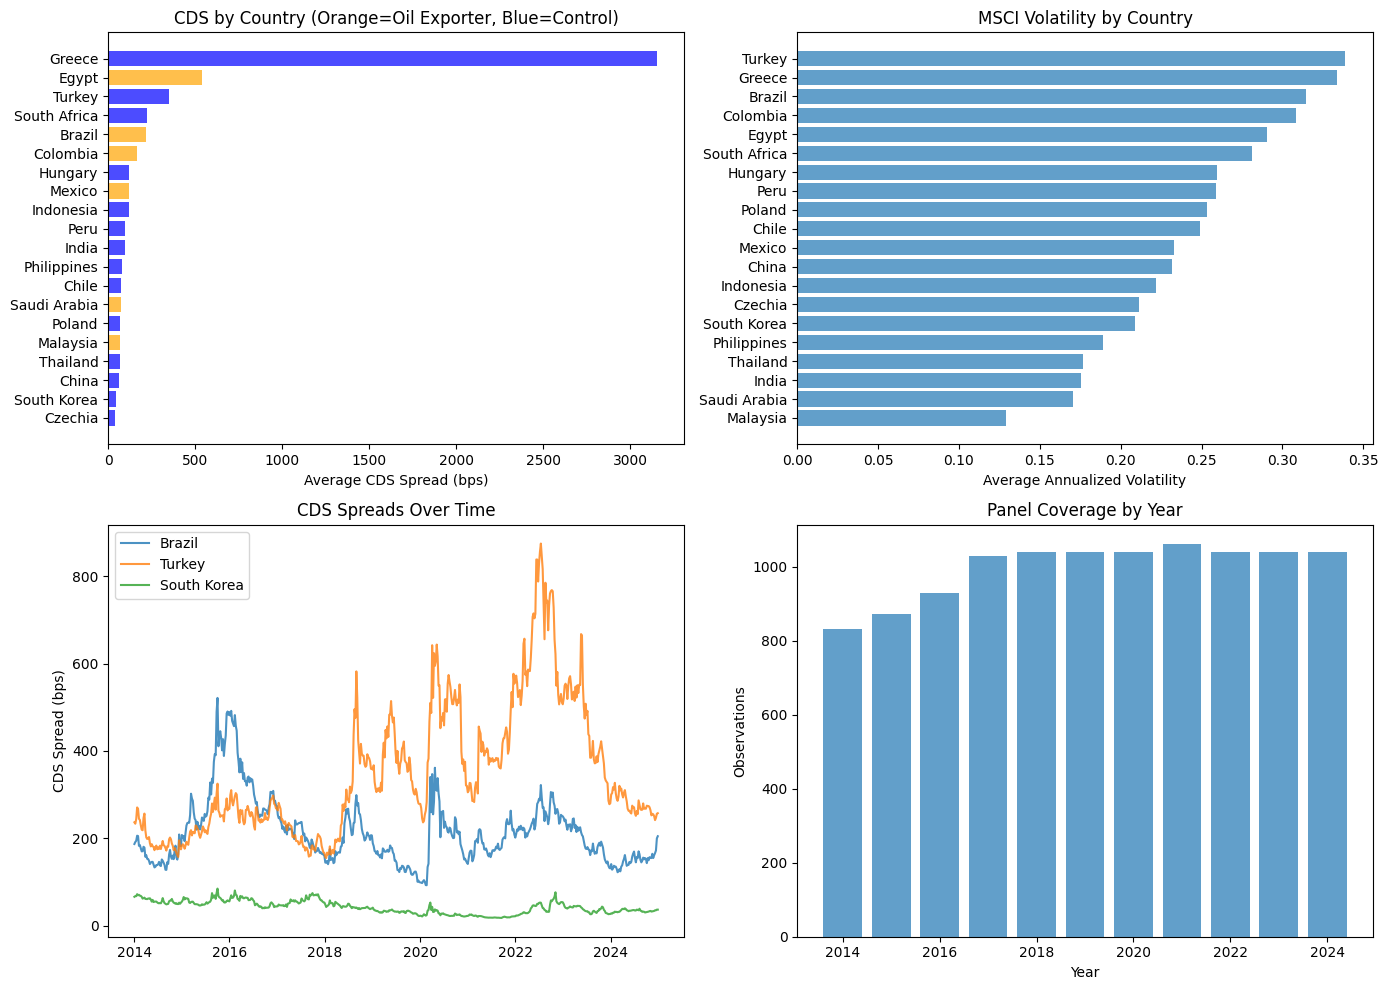

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# CDS by country (average)
ax = axes[0, 0]
cds_avg = panel.groupby('country')['cds_spread'].mean().sort_values(ascending=True)
colors = ['orange' if panel[panel['country']==c]['group'].iloc[0]=='oil_exporter' 
          else 'blue' for c in cds_avg.index]
ax.barh(cds_avg.index, cds_avg.values, color=colors, alpha=0.7)
ax.set_xlabel('Average CDS Spread (bps)')
ax.set_title('CDS by Country (Orange=Oil Exporter, Blue=Control)')

# Volatility by country
ax = axes[0, 1]
vol_avg = panel.groupby('country')['msci_vol_52w'].mean().sort_values(ascending=True)
ax.barh(vol_avg.index, vol_avg.values, alpha=0.7)
ax.set_xlabel('Average Annualized Volatility')
ax.set_title('MSCI Volatility by Country')

# CDS time series (sample)
ax = axes[1, 0]
for country in ['Brazil', 'Turkey', 'South Korea']:
    if country in panel['country'].values:
        df = panel[panel['country'] == country]
        ax.plot(df['date'], df['cds_spread'], label=country, alpha=0.8)
ax.set_ylabel('CDS Spread (bps)')
ax.set_title('CDS Spreads Over Time')
ax.legend()

# Observations per year
ax = axes[1, 1]
panel['year'] = panel['date'].dt.year
obs_year = panel.groupby('year').size()
ax.bar(obs_year.index, obs_year.values, alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Observations')
ax.set_title('Panel Coverage by Year')

plt.tight_layout()
plt.show()

---
## Usage

In model notebooks, load the panel:

```python
panel = pd.read_csv('data/processed/cca_panel.csv', parse_dates=['date'])
```

**Available columns:**
- `country`, `country_clean`, `group`: Country identifiers
- `date`: Week-ending Friday
- `msci_index`: End-of-week MSCI level
- `msci_ret_weekly`: Weekly log return
- `msci_vol_52w`: 52-week rolling annualized volatility
- `debt_st`, `debt_lt`: General Government external debt (USD)
- `default_barrier`: ST + 0.5 × LT
- `cds_spread`: Sovereign CDS spread (bps)
- `rf`: 1-Year Treasury rate (decimal)